# Telecom Customer Churn Prediction

## Project Overview

This project analyzes customer churn behavior using a telecom dataset from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn). The goal is to identify key drivers of customer attrition and build predictive models to support proactive retention strategies.

**Dataset:** 7,043 customer records with 21 features covering demographics, service subscriptions, account details, and billing information.

**Approach:**
1. Exploratory Data Analysis to uncover churn patterns
2. Feature engineering and preprocessing
3. Model comparison: Logistic Regression (baseline) vs. Random Forest (ensemble)
4. Business-driven interpretation of results

**Key Findings:**
- Customer tenure, contract type, and monthly charges are the strongest predictors of churn
- Random Forest achieves 84.5% AUC with 75.7% recall, significantly outperforming Logistic Regression in identifying at-risk customers
- Month-to-month contracts and electronic check payments are strongly associated with higher churn rates

In [415]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Overview

The dataset contains customer-level information from a telecom company, including demographics, account details, and service usage. Each row represents a single customer, and the target variable `Churn` indicates whether the customer has discontinued the service.

In [ ]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [417]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [418]:
df.shape 

(7043, 21)

In [419]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset contains a mix of numerical and categorical variables. Some columns appear to be incorrectly typed (e.g., TotalCharges as object), which will be addressed in the data cleaning step.

In [420]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [421]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## 2. Data Cleaning

The `TotalCharges` column is stored as a string (object type) due to invalid entries such as blank spaces. It is converted to numeric format, coercing invalid values to `NaN` for further inspection.

In [422]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [423]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [424]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']] 

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Missing values were analyzed using .isna().
It was found that missing values occur only in the TotalCharges column.
Further inspection revealed that these correspond to customers with tenure = 0, i.e., new customers who have not accumulated charges yet.
Therefore, missing values were replaced with 0 instead of dropping these records.

In [425]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3. Exploratory Data Analysis

In [426]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [427]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [428]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Approximately 26% of customers have churned, while 74% have not.

<Axes: xlabel='Churn', ylabel='count'>

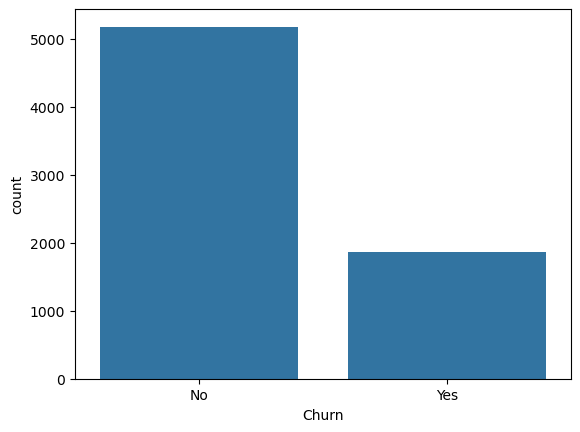

In [429]:
# Plot distribution of target variable 'Churn'
sns.countplot(x='Churn', data=df)

The dataset is moderately imbalanced, with a higher proportion of non-churn customers compared to churned customers. This imbalance should be considered when evaluating model performance, especially when using accuracy as a metric.

In [430]:
def plot_categorical_features(df, columns, target='Churn'):
    n = len(columns)
    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    axes = axes.flatten()
    
    if n == 1:
        axes = [axes]
    
    for i, col in enumerate(columns):
        sns.countplot(x=col, hue=target, data=df, ax=axes[i])
        axes[i].set_title(f'{col} vs {target}')
    
    plt.tight_layout()
    plt.show()

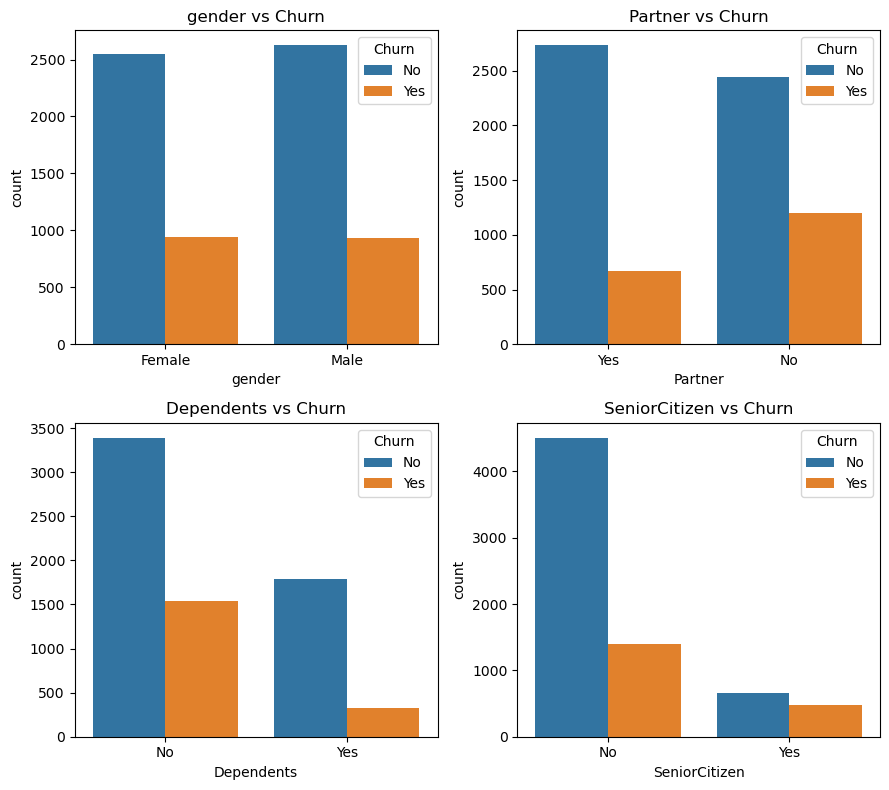

In [431]:
cols = ['gender', 'Partner', 'Dependents', 'SeniorCitizen']

plot_categorical_features(df, cols)

Gender does not show a significant relationship with churn. Other demographic variables such as Partner, Dependents, and SeniorCitizen show limited influence on churn. However, they are retained in the model to allow the algorithm to assess their contribution.

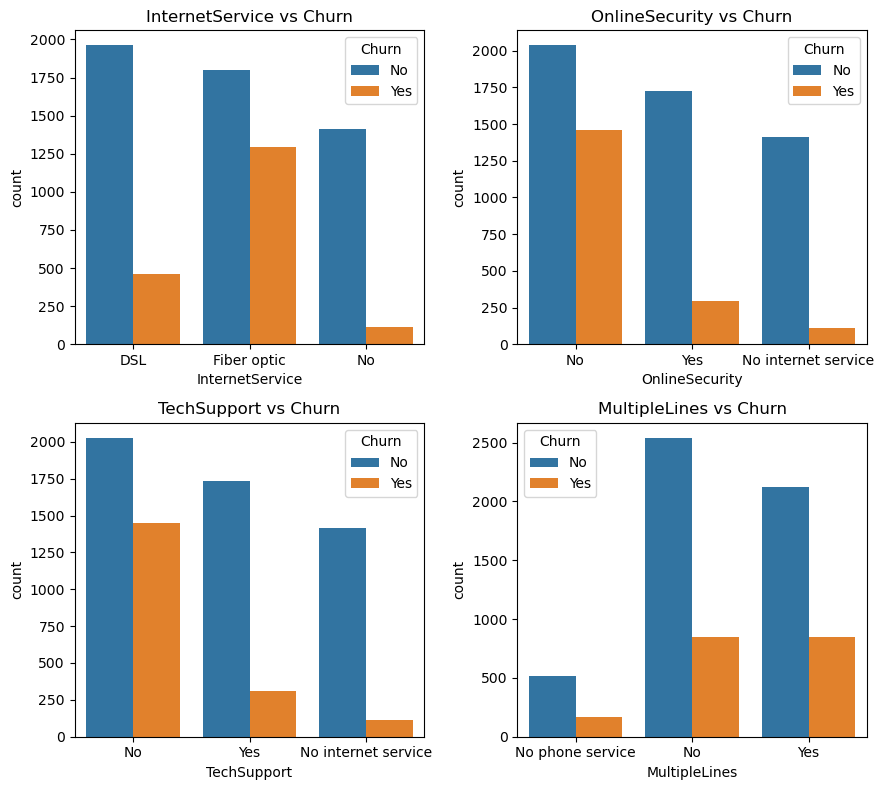

In [432]:
cols = ['InternetService', 'OnlineSecurity', 'TechSupport', 'MultipleLines']

plot_categorical_features(df, cols)

Service-related features show varying levels of influence on churn. OnlineSecurity and TechSupport exhibit a strong relationship with churn, as customers without these services are significantly more likely to leave. InternetService also plays an important role, with fiber optic users showing noticeably higher churn rates compared to DSL users. In contrast, MultipleLines shows little to no clear relationship with churn, indicating that not all service features are equally important predictors.

<Axes: xlabel='Churn', ylabel='tenure'>

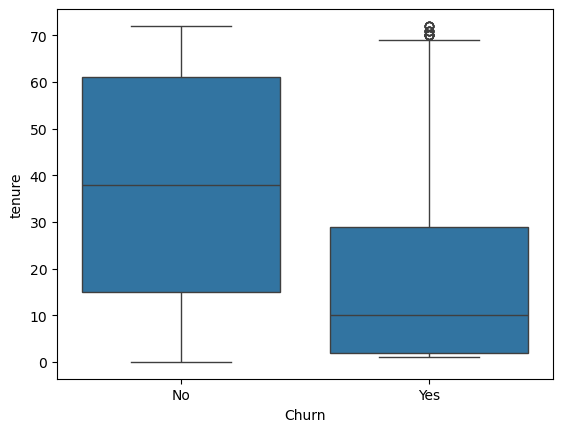

In [433]:
sns.boxplot(x='Churn', y='tenure', data=df)

Customers with longer tenure are significantly less likely to churn, indicating strong retention among long-term users.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

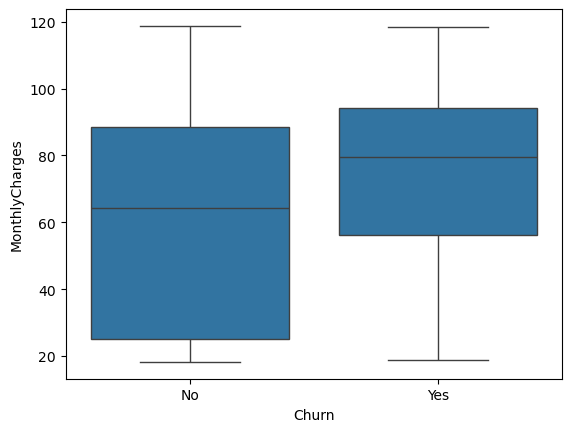

In [434]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

Customers with higher monthly charges show a higher tendency to churn.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

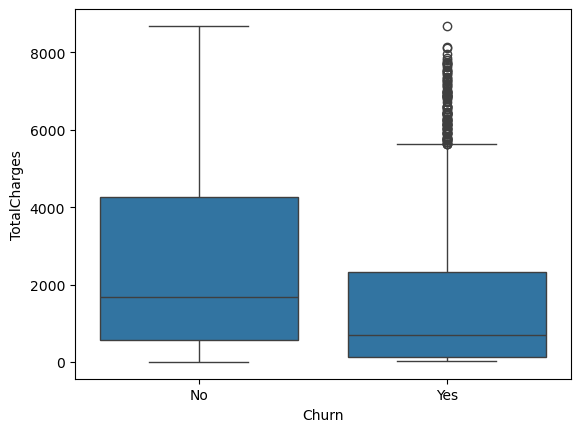

In [435]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

Customers who churn generally have lower total charges, indicating that many customers leave at an early stage.
However, there are also some high-value customers who churn, which may represent an important business concern.

<Axes: xlabel='Contract', ylabel='count'>

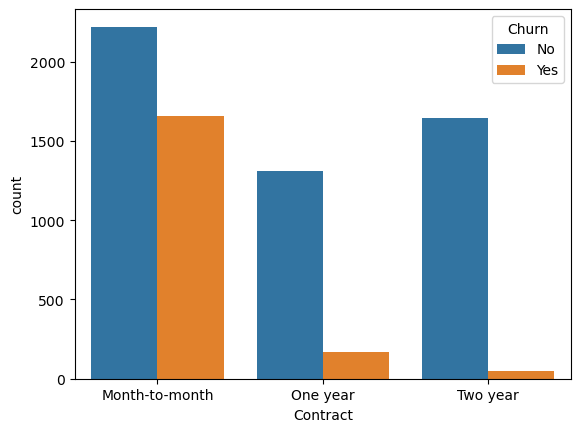

In [436]:
sns.countplot(x='Contract', hue='Churn', data=df)

Customers on month-to-month contracts have a significantly higher churn rate compared to those on longer-term contracts.

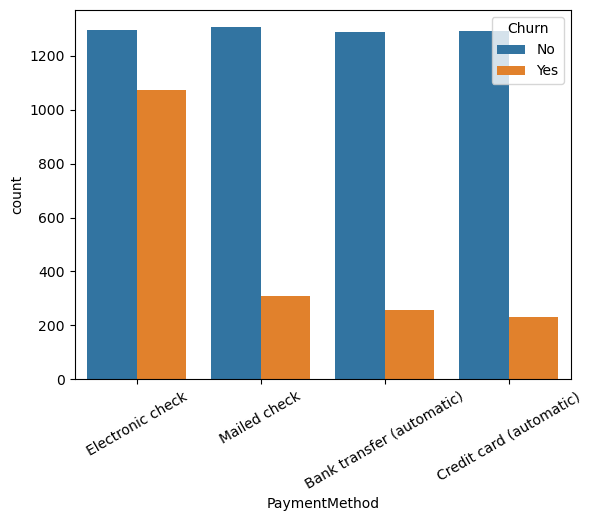

In [437]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

Customers using electronic check show a significantly higher churn rate, while automatic payment methods (such as bank transfer and credit card) are associated with lower churn, suggesting that automated payments may improve customer retention.

<Axes: xlabel='InternetService', ylabel='count'>

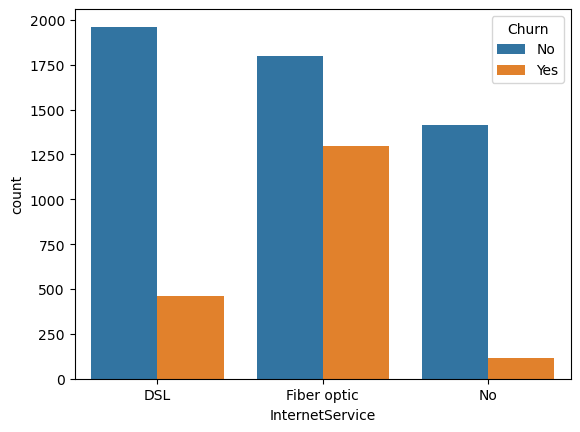

In [438]:
sns.countplot(x='InternetService', hue='Churn', data=df)

Fiber optic users show a higher churn rate compared to DSL users.

### EDA Key Findings

Key factors associated with churn include:

- **Short tenure** — new customers are most vulnerable to leaving
- **Month-to-month contracts** — significantly higher churn rate vs. long-term contracts
- **Higher monthly charges** — price sensitivity is a major driver
- **Electronic check payment** — associated with less commitment and higher attrition
- **Fiber optic internet** — higher churn rate compared to DSL users
- **Lack of support services** — customers without OnlineSecurity or TechSupport are more likely to churn

These insights suggest that customer retention strategies should focus on early-stage engagement, pricing incentives, and promoting value-added services.

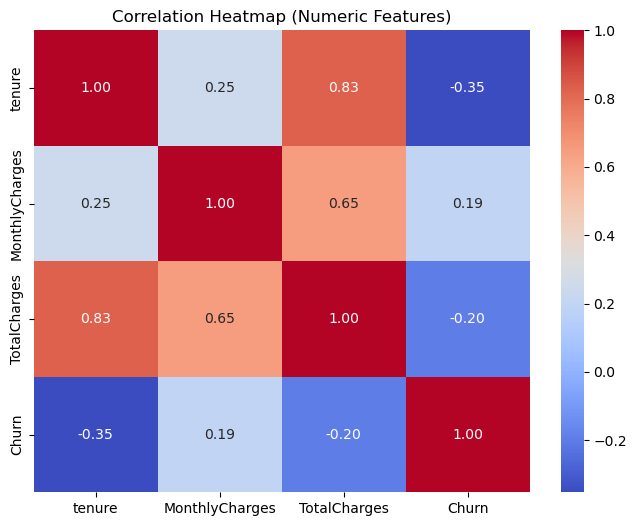

In [439]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(8,6))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

A correlation heatmap was used to examine relationships between numerical features and churn.
Tenure shows a strong negative correlation with churn, indicating that long-term customers are less likely to leave.
Monthly charges are positively correlated with churn, suggesting that higher costs may contribute to customer attrition.
Total charges also show a negative relationship with churn, reflecting that customers with higher cumulative spending tend to stay longer.

## 4. Data Preprocessing

The following preprocessing steps are applied before modeling:

1. **Conditional feature simplification:** Values like "No internet service" and "No phone service" are recoded as "No" to reduce feature cardinality
2. **One-hot encoding:** Categorical variables are converted to binary dummy variables using `pd.get_dummies(drop_first=True)`
3. **Three-way data split:** The data is split into **Train (60%)**, **Test (20%)**, and **Validation (20%)** sets using stratified sampling. The train set is used for model training with cross-validation, the test set for model comparison, and the validation set is held out for final evaluation of the best model only — ensuring an unbiased performance estimate

In [455]:
# =========================
# 1. Copy data
# =========================
df_model = df.copy()

# =========================
# 2. Drop irrelevant columns
# =========================
df_model = df_model.drop(columns=['customerID'], errors='ignore')

# =========================
# 3. Handle conditional features
# =========================
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_cols:
    df_model[col] = df_model[col].replace({'No internet service': 'No'})
df_model['MultipleLines'] = df_model['MultipleLines'].replace({'No phone service': 'No'})

# =========================
# 4. One-hot encoding
# =========================
df_model = pd.get_dummies(df_model, drop_first=True)

# =========================
# 5. Split features and target
# =========================
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# =========================
# 6. Three-way split: Train (60%) / Test (20%) / Validation (20%)
# =========================
from sklearn.model_selection import train_test_split

# First split: 80% train_temp / 20% validation (held out until final evaluation)
X_temp, X_val, y_temp, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% of temp = 60% total (train) / 25% of temp = 20% total (test)
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# =========================
# 7. Verify split sizes and churn rates
# =========================
print(f"Train set:      {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print()
print(f"Train churn rate:      {y_train.mean():.3f}")
print(f"Test churn rate:       {y_test.mean():.3f}")
print(f"Validation churn rate: {y_val.mean():.3f}")

Train set:      4225 samples (60%)
Test set:       1409 samples (20%)
Validation set: 1409 samples (20%)

Train churn rate:      0.265
Test churn rate:       0.265
Validation churn rate: 0.265


After one-hot encoding, the number of features increased as categorical variables were expanded into multiple binary columns.

## 5. Modeling

All models are trained on the **train set (60%)** and evaluated on the **test set (20%)**. 5-fold stratified cross-validation is performed on the training set to assess model stability before test set evaluation. The **validation set (20%)** is reserved exclusively for the final evaluation of the best model.

### 5.1 Logistic Regression

Logistic Regression serves as the baseline model due to its simplicity, interpretability, and effectiveness for binary classification tasks.

In [457]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize model
log_model = LogisticRegression(max_iter=5000, random_state=42)

# 5-fold cross-validation on training set
cv_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Logistic Regression — 5-Fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Fit on full training set and predict on test set
log_model.fit(X_train, y_train)
yhat_test = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

Logistic Regression — 5-Fold CV AUC: 0.849 ± 0.012


In [458]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report

auc_score = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print("=" * 50)
print("Logistic Regression — Test Set Results")
print("=" * 50)
print(classification_report(y_test, yhat_test, target_names=['No Churn', 'Churn']))
print(f"AUC Score: {auc_score:.3f}")

Logistic Regression — Test Set Results
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

AUC Score: 0.836


The Logistic Regression baseline achieves a CV AUC of 0.849 (±0.012), indicating stable performance across folds. On the test set, accuracy is 80%, but recall for the Churn class is only 53%, meaning nearly half of actual churners are missed. This confirms the need for more powerful models.

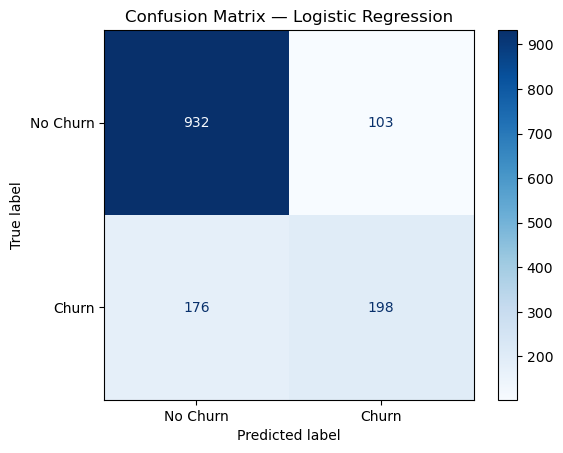

In [459]:
# Confusion Matrix — Logistic Regression
cm = confusion_matrix(y_test, yhat_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

### 5.2 Random Forest

Random Forest is an ensemble method that builds multiple decision trees and combines their predictions through majority voting. It is well-suited for this task because it captures non-linear relationships and feature interactions that logistic regression may miss. The `class_weight='balanced'` parameter is used to address the class imbalance in the dataset. Additionally, Random Forest provides built-in feature importance scores, which help identify the most influential predictors of churn.

In [460]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=10,
    min_samples_leaf=4, class_weight='balanced', random_state=42, n_jobs=-1
)

# 5-fold cross-validation
rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Random Forest — 5-Fold CV AUC: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")

# Fit and predict on test set
rf_model.fit(X_train, y_train)
rf_yhat_test = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

Random Forest — 5-Fold CV AUC: 0.849 ± 0.013


In [461]:
rf_auc = roc_auc_score(y_test, rf_y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_prob)

print("=" * 50)
print("Random Forest — Test Set Results")
print("=" * 50)
print(classification_report(y_test, rf_yhat_test, target_names=['No Churn', 'Churn']))
print(f"AUC Score: {rf_auc:.3f}")

Random Forest — Test Set Results
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

AUC Score: 0.837


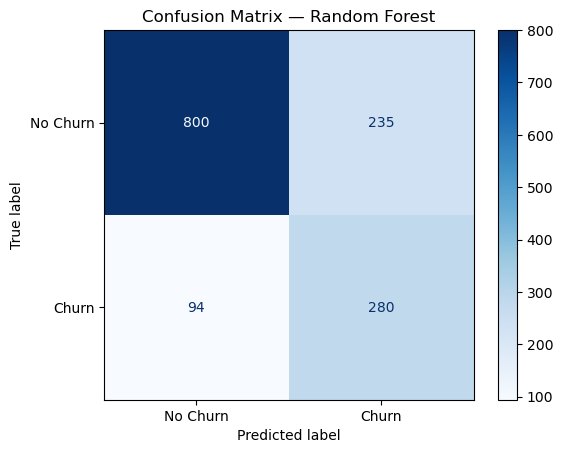

In [462]:
# Confusion Matrix — Random Forest
rf_cm = confusion_matrix(y_test, rf_yhat_test)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=['No Churn', 'Churn'])
disp_rf.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

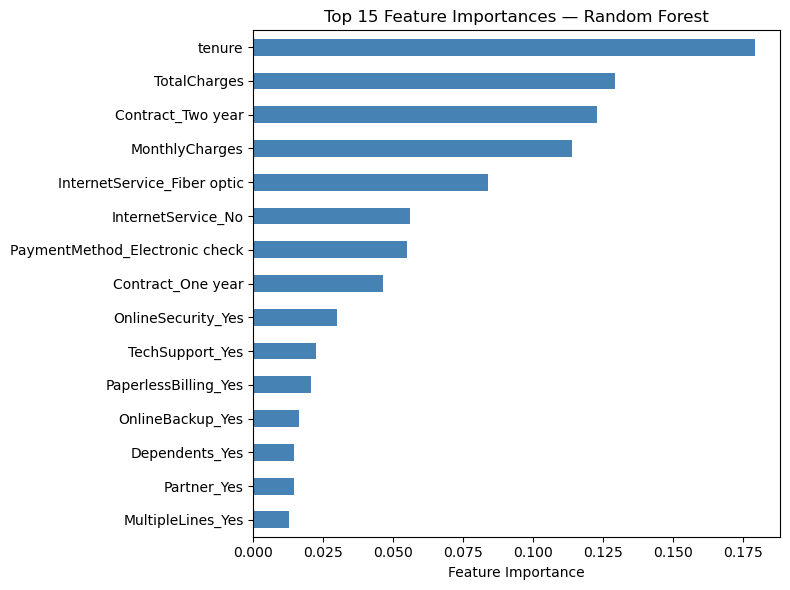

In [463]:
# ==============================
# Feature Importance (Top 15)
# ==============================
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.nlargest(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

Random Forest achieves a similar CV AUC (0.849) to Logistic Regression, but with `class_weight='balanced'`, it significantly improves churn recall from 53% to 75% — catching far more at-risk customers at the cost of more false positives (precision drops to 54%). Feature importance confirms that tenure, charges, and contract type are the dominant predictors.

### 5.3 XGBoost (Gradient Boosting)

XGBoost builds an ensemble of decision trees **sequentially**, where each new tree corrects the errors of the previous ones. It often achieves state-of-the-art performance on tabular data.

- `scale_pos_weight` is set to the class imbalance ratio to handle the skewed churn distribution.
- We use the same 5-fold stratified cross-validation for a fair comparison.

In [465]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Calculate class imbalance ratio for scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
imbalance_ratio = neg / pos
print(f"Class imbalance ratio (neg/pos): {imbalance_ratio:.2f}")

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss'
)

# 5-fold stratified cross-validation on training set
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\nXGBoost 5-Fold CV AUC: {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

# Fit on full training set and predict on test set
xgb_model.fit(X_train, y_train)
xgb_yhat_test = xgb_model.predict(X_test)
xgb_y_prob = xgb_model.predict_proba(X_test)[:, 1]

Class imbalance ratio (neg/pos): 2.77

XGBoost 5-Fold CV AUC: 0.832 ± 0.011


In [466]:
from sklearn.metrics import classification_report, roc_auc_score

xgb_auc = roc_auc_score(y_test, xgb_y_prob)
print("XGBoost — Test Set Performance")
print("=" * 40)
print(f"Test AUC: {xgb_auc:.3f}")
print()
print(classification_report(y_test, xgb_yhat_test, target_names=['No Churn', 'Churn']))

XGBoost — Test Set Performance
Test AUC: 0.825

              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.53      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



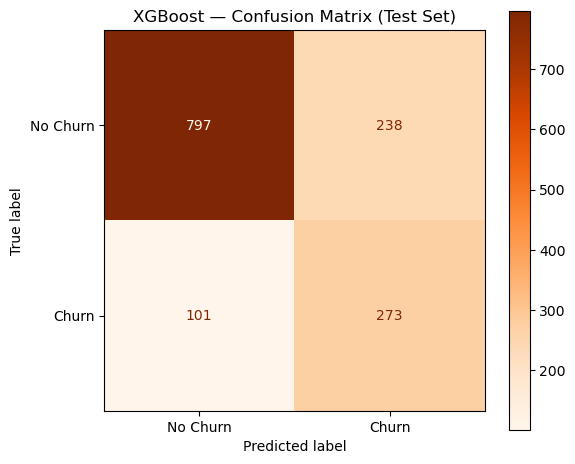

In [467]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
disp_xgb = ConfusionMatrixDisplay.from_predictions(y_test, xgb_yhat_test, display_labels=['No Churn', 'Churn'], cmap='Oranges', ax=ax)
ax.set_title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

**XGBoost Interpretation:** XGBoost achieves a CV AUC of 0.832, slightly below the other two models. Its churn recall (73%) and precision (53%) are comparable to Random Forest. The gradient boosting approach with `scale_pos_weight` effectively handles the class imbalance, but does not outperform the simpler models on this dataset — likely because the feature space is relatively low-dimensional and the relationships are well-captured by Random Forest.

### 5.4 Model Explainability (SHAP)

While feature importance from tree-based models tells us **which** features matter, SHAP (SHapley Additive exPlanations) goes further by showing **how** each feature impacts predictions — both globally and at the individual customer level. We apply SHAP to the **Random Forest** model, which achieved the highest CV AUC (0.849).

- **SHAP Summary Plot (Global):** Shows the direction and magnitude of each feature's impact across all predictions. Unlike basic feature importance, it reveals whether a feature pushes predictions toward churn or retention.
- **SHAP Waterfall Plot (Local):** Explains a single prediction — why the model predicted a specific customer would churn or stay. This is essential for actionable decision-making in customer retention.

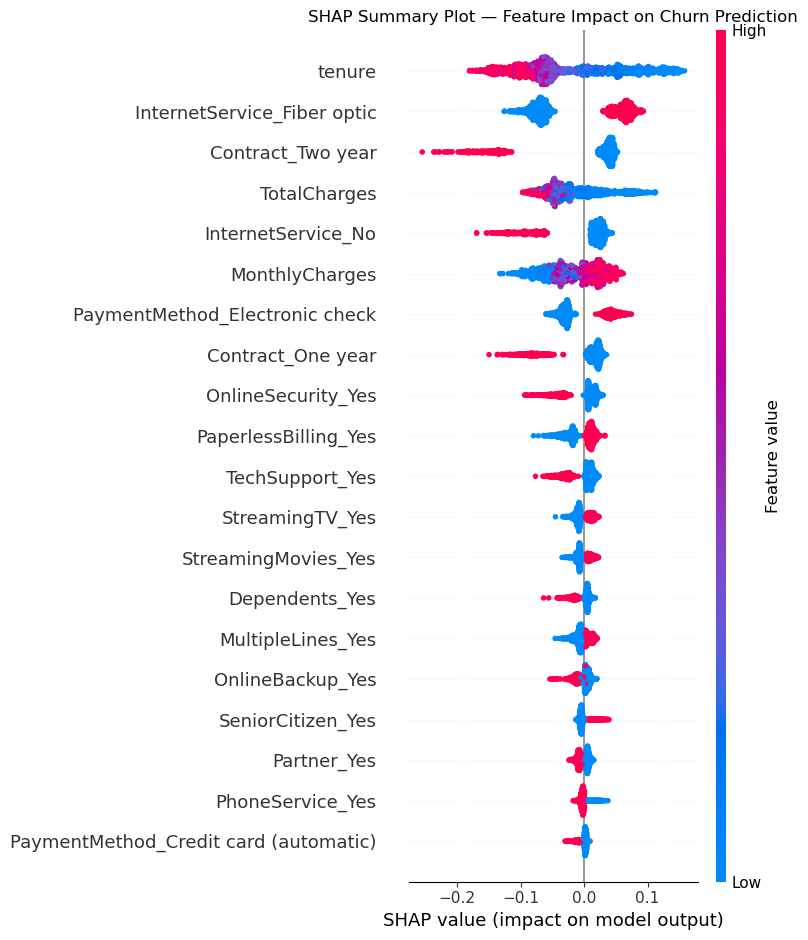

In [468]:
import shap

# Use TreeExplainer for Random Forest (exact & fast)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# ==============================
# SHAP Summary Plot (Global)
# ==============================
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn Prediction')
plt.tight_layout()
plt.show()

Customer index: 8
Predicted: Churn
Actual:    Churn



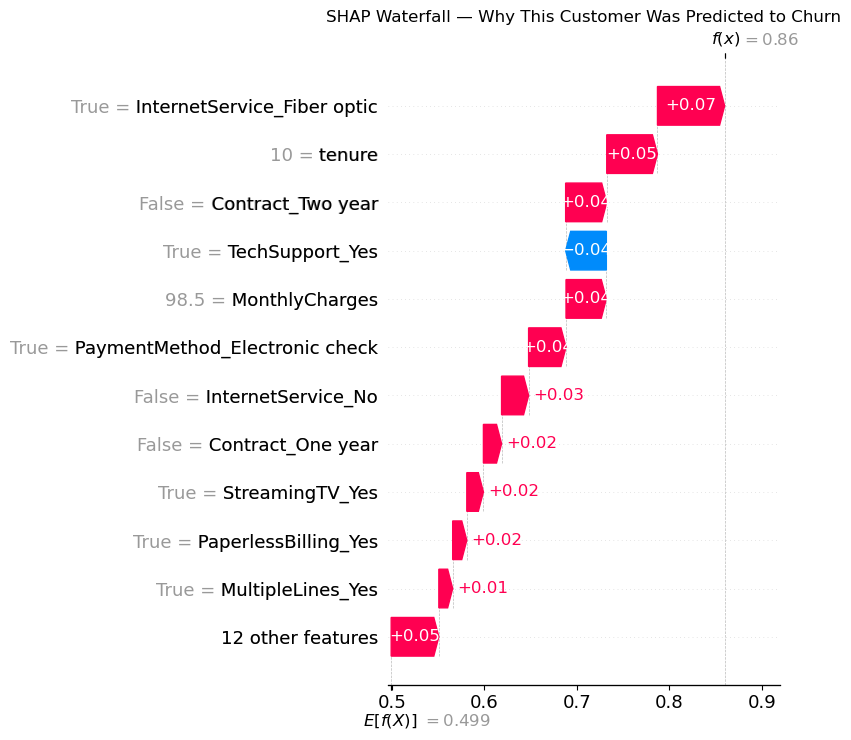

In [469]:
# ==============================
# SHAP Waterfall Plot (Local Explanation)
# ==============================
# Select a correctly predicted churner (True Positive)
tp_indices = np.where((rf_yhat_test == 1) & (y_test.values == 1))[0]
sample_idx = tp_indices[0]

print(f"Customer index: {sample_idx}")
print(f"Predicted: {'Churn' if rf_yhat_test[sample_idx] == 1 else 'No Churn'}")
print(f"Actual:    {'Churn' if y_test.iloc[sample_idx] == 1 else 'No Churn'}")
print()

shap.waterfall_plot(shap_values[sample_idx, :, 1], max_display=12, show=False)
plt.title('SHAP Waterfall — Why This Customer Was Predicted to Churn')
plt.tight_layout()
plt.show()

### SHAP Interpretation

**Global Insights (Summary Plot):**
The SHAP summary plot reveals how each feature contributes to the model's churn predictions across all customers:
- **Contract (Two year / One year):** Long-term contracts have the strongest protective effect against churn (blue dots push predictions left, toward "No Churn")
- **Tenure:** Higher tenure (red dots) strongly pushes predictions toward retention, while low tenure increases churn risk
- **MonthlyCharges:** Higher values push toward churn, confirming that price sensitivity is a key driver
- **InternetService (Fiber optic):** Having fiber optic service increases churn probability
- **TechSupport / OnlineSecurity:** Having these services reduces churn risk

**Local Insight (Waterfall Plot):**
The waterfall plot shows the reasoning behind a single prediction. For the selected churned customer, we can see exactly which factors pushed the model toward predicting churn — making the model's decision transparent and actionable for customer service teams.

This level of explainability is critical for real-world deployment: retention teams can use individual SHAP explanations to design personalized interventions (e.g., offering a contract upgrade to a customer whose short tenure and month-to-month contract are driving churn risk).

## 6. Model Comparison & Conclusion

=== Test Set Comparison ===
                     Accuracy  Precision  Recall  F1-Score    AUC
Logistic Regression     0.802      0.658   0.529     0.587  0.836
Random Forest           0.767      0.544   0.749     0.630  0.837
XGBoost                 0.759      0.534   0.730     0.617  0.825



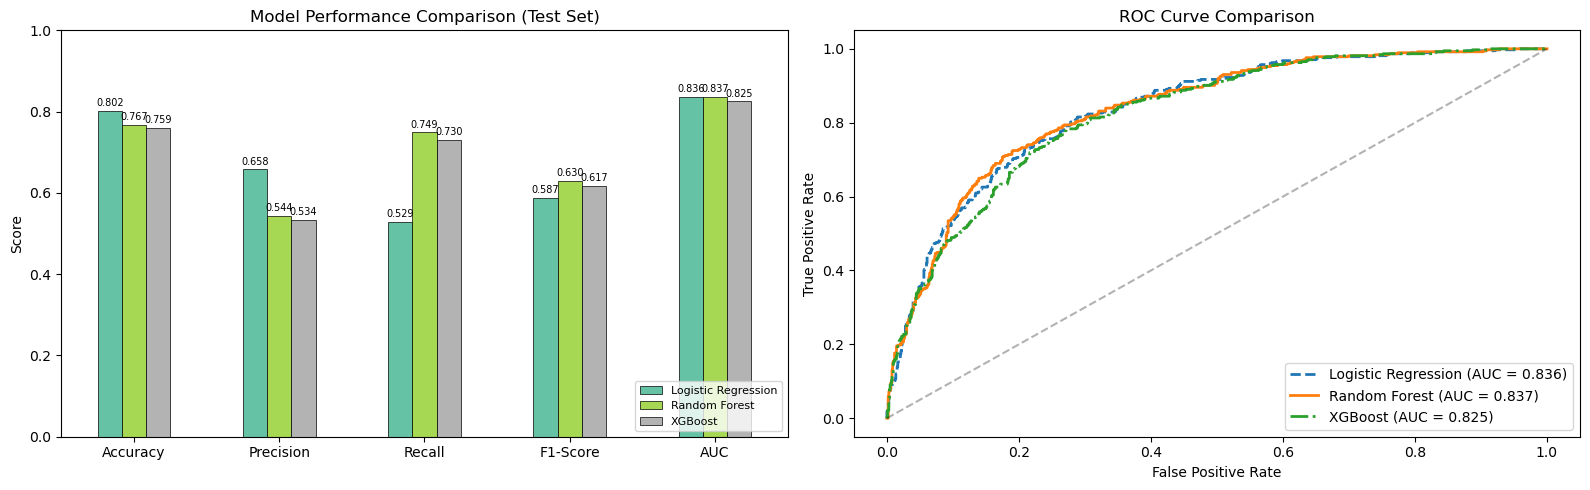


FINAL VALIDATION — Random Forest (Best CV AUC)
Validation AUC: 0.844

              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [470]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# ==============================
# Model Comparison on Test Set
# ==============================
metrics = {
    'Accuracy':  [accuracy_score(y_test, yhat_test), accuracy_score(y_test, rf_yhat_test), accuracy_score(y_test, xgb_yhat_test)],
    'Precision':  [precision_score(y_test, yhat_test), precision_score(y_test, rf_yhat_test), precision_score(y_test, xgb_yhat_test)],
    'Recall':     [recall_score(y_test, yhat_test), recall_score(y_test, rf_yhat_test), recall_score(y_test, xgb_yhat_test)],
    'F1-Score':   [f1_score(y_test, yhat_test), f1_score(y_test, rf_yhat_test), f1_score(y_test, xgb_yhat_test)],
    'AUC':        [auc_score, rf_auc, xgb_auc]
}

comparison_df = pd.DataFrame(metrics, index=['Logistic Regression', 'Random Forest', 'XGBoost']).round(3)
print("=== Test Set Comparison ===")
print(comparison_df.to_string())
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart comparison
comparison_df.T.plot(kind='bar', ax=axes[0], rot=0, colormap='Set2', edgecolor='black', linewidth=0.5)
axes[0].set_title('Model Performance Comparison (Test Set)')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right', fontsize=8)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=7, padding=2)

# ROC comparison
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_y_prob)
axes[1].plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', linestyle='--', linewidth=2)
axes[1].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)
axes[1].plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})', linestyle='-.', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# ==============================
# Final Validation Set Evaluation (Best Model: Random Forest)
# ==============================
print("\n" + "=" * 50)
print("FINAL VALIDATION — Random Forest (Best CV AUC)")
print("=" * 50)
rf_val_pred = rf_model.predict(X_val)
rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
rf_val_auc = roc_auc_score(y_val, rf_val_prob)

print(f"Validation AUC: {rf_val_auc:.3f}")
print()
print(classification_report(y_val, rf_val_pred, target_names=['No Churn', 'Churn']))

### Summary

**Test Set Comparison (3 Models):**

| Metric | Logistic Regression | Random Forest | XGBoost | Winner |
|--------|:---:|:---:|:---:|:---:|
| Accuracy | 0.802 | 0.767 | 0.759 | LR |
| Precision (Churn) | 0.658 | 0.544 | 0.534 | LR |
| **Recall (Churn)** | **0.529** | **0.749** | **0.730** | **RF** |
| F1-Score (Churn) | 0.587 | 0.630 | 0.617 | RF |
| AUC | 0.836 | 0.837 | 0.825 | RF |
| CV AUC (5-fold) | 0.849 ± 0.012 | 0.849 ± 0.013 | 0.832 ± 0.011 | LR / RF |

**Final Validation Set Results (Random Forest):**

| Metric | Value |
|--------|:---:|
| Validation AUC | 0.844 |
| Churn Recall | 75% |
| Churn Precision | 54% |
| Churn F1 | 0.63 |

The held-out validation set confirms that Random Forest generalizes well — its Validation AUC (0.844) is consistent with the Test AUC (0.837) and CV AUC (0.849), showing no evidence of overfitting.

### Key Findings

- **Logistic Regression** provides the highest accuracy (80.2%) and precision (65.8%), making it suitable when minimizing false alarms is a priority.
- **Random Forest** delivers the best recall (74.9%) and F1-score (0.630), catching ~75 out of every 100 actual churners. It also leads in AUC and CV AUC.
- **XGBoost** performs comparably to RF but slightly lower across all metrics on this dataset. The relatively low-dimensional feature space favors RF's parallel ensemble over XGBoost's sequential boosting.
- All three models agree that **tenure, contract type, and monthly charges** are the most important churn predictors.

### Business Recommendations

Based on the analysis, the following strategies are recommended to reduce customer churn:

1. **Early engagement programs:** Tenure is the strongest predictor of churn. Customers in their first few months are most at risk. Onboarding programs and early satisfaction check-ins can improve retention.

2. **Contract incentives:** Month-to-month customers have dramatically higher churn rates. Offering discounts or value-added benefits for annual contracts could reduce attrition.

3. **Pricing review:** Higher monthly charges correlate with churn. Competitive pricing, bundled discounts, or loyalty pricing for long-term customers may help.

4. **Payment method migration:** Electronic check users show higher churn. Encouraging enrollment in automatic payment methods (bank transfer, credit card) could improve retention.

5. **Service bundling:** Customers without OnlineSecurity and TechSupport are more likely to churn. Promoting these add-on services can improve satisfaction and reduce attrition.

### Model Recommendation

For deployment in a churn prevention system, **Random Forest is recommended** as the primary model:
- **Highest churn recall (74.9%)** — catches the most at-risk customers
- **Best F1-score (0.630)** — best balance of precision and recall
- **Highest AUC (0.837)** — best overall discriminative ability
- **Validated at 0.844 AUC** on held-out data — confirms generalization
- **SHAP-compatible** — provides transparent, customer-level explanations for actionable retention strategies

In a business context, the cost of losing a customer (~$500–$1000/year in recurring revenue) typically far exceeds the cost of a retention campaign (~$20–$50 per contact), making high recall the priority metric.